<a href="https://colab.research.google.com/github/JordanBaker78/Data205_JordanBaker/blob/main/DATA205_Rmagic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Colab uses IPython Magics (specifically rpy2) to let the two languages talk to each other.

In Colab, Python is the "host," and you "send" data to R using the %Rpush command.



**1. The Setup (Run this first)**
Colab comes with rpy2 pre-installed. You just need to load the extension to enable R cells.

In [ ]:
# Load the R magic extension
%load_ext rpy2.ipython

**2. Python: Data Acquisition**
We’ll start in Python to fetch ISS data via the API using requests.

In [ ]:
import requests
import pandas as pd

# 1. Get the data
url = "http://api.open-notify.org/iss-now.json"
response = requests.get(url)
data = response.json()

# 2. Create a Pandas DataFrame
df_python = pd.DataFrame([{
    'lat': float(data['iss_position']['latitude']),
    'lon': float(data['iss_position']['longitude']),
    'timestamp': data['timestamp']
}])

print("Data captured in Python:")
print(df_python)

Data captured in Python:
       lat       lon   timestamp
0  48.1304 -112.4217  1774989139


**3. The Handoff:** Sending Python Data to R

To move the df_python variable into the R environment, use the %Rpush magic command.

In [ ]:
# Push the dataframe from Python to R
%Rpush df_python

**4. R: Statistical Summary or Plotting**

Now, we tell the cell to run R code by putting %%R at the very top. The variable df_python is now available as an R data frame

Keep up to date with changes at https://tidyverse.org/blog/


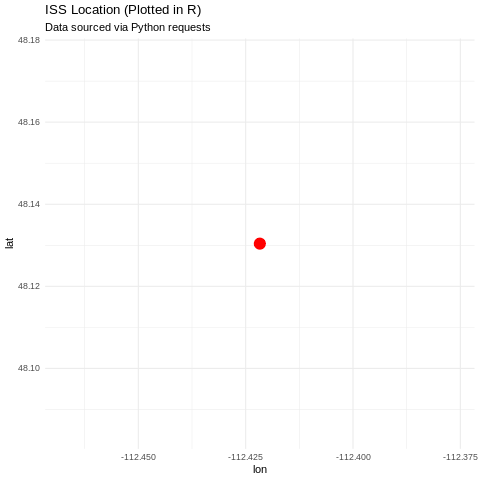

In [ ]:
%%R
# This entire cell is now R code
library(ggplot2)

summary(df_python)

# Create a quick plot in R using the Python data
ggplot(df_python, aes(x=lon, y=lat)) +
  geom_point(color="red", size=5) +
  labs(title="ISS Location (Plotted in R)",
       subtitle="Data sourced via Python requests") +
  theme_minimal()

**5. Bringing it Back: R to Python**

If you do some heavy lifting in R and want the result back in Python, you use the -o (output) flag.

In [ ]:
%%R -o r_result
# Create a new variable in R
r_result <- paste("The ISS was at longitude", df_python$lon, "when checked.")
r_result


[1] "The ISS was at longitude -112.4217 when checked."


Now, check the variable back in a standard Python cell:

In [ ]:
print(f"Back in Python: {r_result[0]}")

Back in Python: The ISS was at longitude -112.4217 when checked.


6.  **Dedicated R code cell:**  
Here is the code we ran in the notebook with the R runtime.  Here, we simply use the R magic indicator at the top of the cell, then run the R code.

tibble [1,924,665 × 5] (S3: tbl_df/tbl/data.frame)
 $ year: num [1:1924665] 1880 1880 1880 1880 1880 1880 1880 1880 1880 1880 ...
 $ sex : chr [1:1924665] "F" "F" "F" "F" ...
 $ name: chr [1:1924665] "Mary" "Anna" "Emma" "Elizabeth" ...
 $ n   : int [1:1924665] 7065 2604 2003 1939 1746 1578 1472 1414 1320 1288 ...
 $ prop: num [1:1924665] 0.0724 0.0267 0.0205 0.0199 0.0179 ...


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/babynames_1.0.1.tar.gz'
Content type 'application/x-gzip' length 5508752 bytes (5.3 MB)
downloaded 5.3 MB


The downloaded source packages are in
	‘/tmp/RtmpaW6ND0/downloaded_packages’


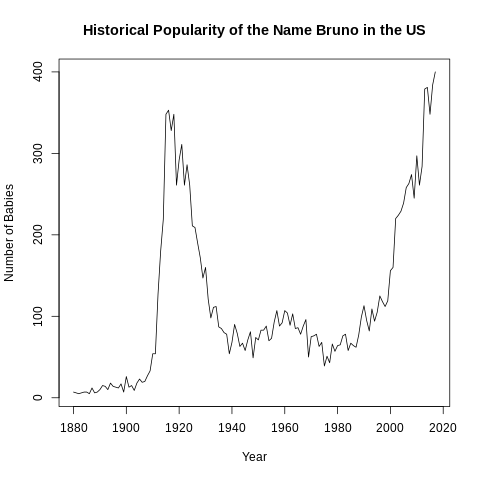

In [ ]:
%%R

# Install the necessary package directly in the Colab cell
install.packages("babynames")

# Load the library
library(babynames)

# Inspect the structure of the dataset
str(babynames)

# Filter the dataset for a specific name
bruno_df <- babynames[babynames$name == "Bruno", ]

# Plot the historical popularity of the name
plot(x = bruno_df$year,
    y = bruno_df$n,
    type = "l",
    main = "Historical Popularity of the Name Bruno in the US",
    xlab = "Year",
    ylab = "Number of Babies")
